<a href="https://colab.research.google.com/github/bellajelly/honors-thesis-2026/blob/main/honors_thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# What files exist in the repo
from huggingface_hub import list_repo_files

for f in list_repo_files("Mhdvav2323/bipolar-mixed-states-synthetic", repo_type="dataset"):
    print(f)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


.gitattributes
CITATION.cff
LICENSE
README.md
data/dataset_cdisc_odm.xml
data/dataset_fhir_bundle.json
data/dataset_ndjson.ndjson
data/dataset_psychological.csv
data/dataset_psychological.db
data/dataset_psychological.parquet
data/dataset_redcap.csv
data/dataset_stata.dta
data/dataset_summary.json
documentation/DATA_DICTIONARY.md
documentation/LIMITATIONS.md
documentation/METHODOLOGY.md
examples/quickstart.ipynb
metadata/schema.yaml
reports/analysis_findings.json
reports/comprehensive_analysis.txt
reports/privacy_validation.md
reports/quality_report.md
visualizations/3d_clinical_space.png
visualizations/3d_longitudinal_trajectories.png
visualizations/3d_pca_diagnosis.png
visualizations/3d_psychological_space.png
visualizations/3d_tsne_clustering.png
visualizations/correlations.png
visualizations/diagnosis_distribution.png
visualizations/distributions.png
visualizations/interactive_3d_clinical.html
visualizations/interactive_3d_pca.html
visualizations/longitudinal_trends.png
visualizati

In [2]:
# Load the main file
import pandas as pd

df = pd.read_csv("hf://datasets/Mhdvav2323/bipolar-mixed-states-synthetic/data/dataset_psychological.csv")

In [3]:
# Shape and columns
print(df.shape)
print(df.columns.tolist())

# Data types and nulls
df.info()

# Quick look at distributions
df.describe()

# What the actual rows look like
df.head(10)

(5550, 35)
['patient_id', 'age', 'sex', 'diagnosis', 'visit_number', 'ymrs', 'hamd', 'cgi_bp', 'madrs', 'bprs', 'gaf', 'phq9', 'visit_date', 'age_bucket', 'ymrs_discrete', 'medication_1', 'medication_1_dose', 'medication_2', 'medication_2_dose', 'adverse_events', 'identity_crisis', 'identity_crisis_severity', 'narrative_disruption_type', 'sleep_aversion', 'sleep_aversion_severity', 'perceived_sleep_waste', 'average_sleep_hours', 'stimulant_misuse', 'stimulant_type', 'stimulant_dose', 'dose_exceeds_therapeutic', 'polypharmacy_conflict', 'sedative_type', 'sedative_dose', 'contradiction_severity']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5550 entries, 0 to 5549
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 5550 non-null   int64  
 1   age                        5550 non-null   int64  
 2   sex                        5550 non-null   object 
 3   diagno

,patient_id,age,sex,diagnosis,visit_number,ymrs,hamd,cgi_bp,madrs,bprs,...,perceived_sleep_waste,average_sleep_hours,stimulant_misuse,stimulant_type,stimulant_dose,dose_exceeds_therapeutic,polypharmacy_conflict,sedative_type,sedative_dose,contradiction_severity
0,0,37,F,F31.60,1,41.1,31.1,4.5,39.5,66.7,...,True,4.6,True,Methylphenidate,104.9,True,True,Lorazepam,5.40,10.0
1,0,61,M,F31.60,2,45.8,38.6,4.5,38.2,31.9,...,True,2.7,False,NaN,0.0,False,False,NaN,0.00,0.0
2,0,38,F,F31.60,3,20.3,34.6,1.0,40.0,43.0,...,True,4.2,True,Methylphenidate,82.8,True,True,Quetiapine_PRN,145.26,10.0
3,0,61,F,F31.60,4,34.2,19.8,5.5,49.7,72.0,...,True,4.4,False,NaN,0.0,False,False,NaN,0.00,0.0
4,0,52,F,F31.60,5,40.5,38.6,6.3,32.0,60.4,...,True,4.9,False,NaN,0.0,False,False,NaN,0.00,0.0
5,0,39,M,F31.60,6,37.5,8.0,4.8,0.0,24.0,...,True,4.3,True,Methylphenidate,79.1,True,True,Zolpidem,14.67,9.5
6,0,31,F,F31.60,7,36.6,8.0,2.7,3.3,24.0,...,True,5.4,False,NaN,0.0,False,False,NaN,0.00,0.0
7,1,61,M,F31.60,1,42.3,8.0,4.4,0.0,77.1,...,False,4.2,True,Methylphenidate,84.2,True,False,NaN,0.00,0.0
8,1,33,Other,F31.60,2,23.4,22.5,5.9,0.0,83.4,...,True,5.5,False,NaN,0.0,False,False,NaN,0.00,0.0
9,1,48,F,F31.60,3,30.1,8.0,2.8,17.2,62.4,...,False,5.1,True,Amphetamine,58.9,True,True,Clonazepam,2.17,7.7


In [4]:
visit_counts = df.groupby('patient_id')['visit_number'].max()
print(visit_counts.describe())
print(visit_counts.value_counts().sort_index())

print(df['diagnosis'].value_counts())

count    800.000000
mean       6.992500
std        0.086331
min        6.000000
25%        7.000000
50%        7.000000
75%        7.000000
max        7.000000
Name: visit_number, dtype: float64
visit_number
6      6
7    794
Name: count, dtype: int64
diagnosis
F31.60    1750
F31.62    1050
F31.64     700
F31.61     683
F31.63     682
F31.89     345
F31.75     340
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

# Track a single patient's trajectory across visits
patient = df[df['patient_id'] == 0].sort_values('visit_number')
print(patient[['visit_number', 'ymrs', 'hamd', 'madrs', 'average_sleep_hours']])

   visit_number  ymrs  hamd  madrs  average_sleep_hours
0             1  41.1  31.1   39.5                  4.6
1             2  45.8  38.6   38.2                  2.7
2             3  20.3  34.6   40.0                  4.2
3             4  34.2  19.8   49.7                  4.4
4             5  40.5  38.6   32.0                  4.9
5             6  37.5   8.0    0.0                  4.3
6             7  36.6   8.0    3.3                  5.4


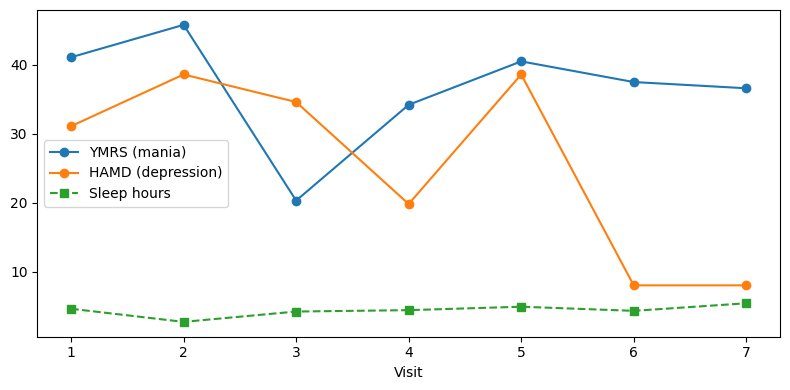

In [ ]:
# Plot mania vs depression scores over visits for one patient
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(patient['visit_number'], patient['ymrs'], marker='o', label='YMRS (mania)')
ax.plot(patient['visit_number'], patient['hamd'], marker='o', label='HAMD (depression)')
ax.plot(patient['visit_number'], patient['average_sleep_hours'], marker='s', linestyle='--', label='Sleep hours')
ax.set_xlabel('Visit')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# For each patient, compute mean and std of YMRS and HAMD across visits
trajectory_stats = df.groupby('patient_id')[['ymrs', 'hamd', 'average_sleep_hours']].agg(['mean', 'std'])
trajectory_stats.columns = ['_'.join(col) for col in trajectory_stats.columns]
print(trajectory_stats.describe())

        ymrs_mean    ymrs_std   hamd_mean    hamd_std  \
count  800.000000  800.000000  800.000000  800.000000   
mean    29.543160   10.388975   18.106379   10.904321   
std      6.902282    3.682296    5.029519    3.221845   
min      6.000000    0.000000    2.300000    0.000000   
25%     27.857143    8.795315   15.625595    9.607181   
50%     30.748571   11.117961   18.592857   11.468456   
75%     33.675000   12.796437   21.457143   12.981388   
max     41.614286   18.985320   31.042857   18.954846   

       average_sleep_hours_mean  average_sleep_hours_std  
count                800.000000               800.000000  
mean                   5.427944                 1.561420  
std                    0.790606                 0.520512  
min                    3.685714                 0.000000  
25%                    4.885119                 1.413873  
50%                    5.357143                 1.681198  
75%                    5.785714                 1.881647  
max           

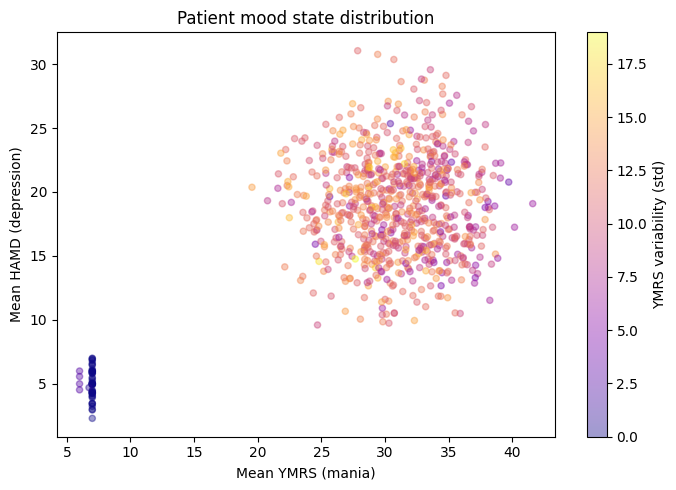

In [ ]:
# Plot YMRS vs HAMD mean per patient — where do patients cluster in mood space?
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(trajectory_stats['ymrs_mean'], trajectory_stats['hamd_mean'],
            alpha=0.4, s=20, c=trajectory_stats['ymrs_std'], cmap='plasma')
plt.colorbar(label='YMRS variability (std)')
plt.xlabel('Mean YMRS (mania)')
plt.ylabel('Mean HAMD (depression)')
plt.title('Patient mood state distribution')
plt.tight_layout()
plt.show()